In [6]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from sklearn.metrics import classification_report, confusion_matrix
import os

In [7]:
train_dir = r"D:\\AII\\tumor\\Training"
test_dir= r"D:\\AII\\tumor\\Testing"

In [8]:
datagen=ImageDataGenerator(
    rescale=1.0/255,
    validation_split=0.2
)


train_data = datagen.flow_from_directory(
    train_dir,  
    target_size=(128,128),
    batch_size=32,
    subset="training",
    class_mode="binary"
)

val_data = datagen.flow_from_directory(
    train_dir,  
    target_size=(128,128),
    batch_size=32,
    subset="validation",
    class_mode="binary"
)

test_datagen=ImageDataGenerator(
    rescale=1./255,)
test_data=test_datagen.flow_from_directory(test_dir,target_size=(128,128),batch_size=32,class_mode="binary",shuffle=False)

Found 4571 images belonging to 4 classes.
Found 1141 images belonging to 4 classes.
Found 1311 images belonging to 4 classes.


In [9]:
model=Sequential([
    Conv2D(32,(3,3),activation="relu",input_shape=(128,128,3)),
    MaxPooling2D(2,2),
    Conv2D(64,(3,3),activation="relu"),
    MaxPooling2D(2,2),
    Conv2D(128,(3,3),activation="relu"),
    MaxPooling2D(2,2),
    Flatten(), 
    Dense(128,activation="relu"), 
    Dropout(0.2),
    Dense(1,activation="sigmoid")
    
])

In [10]:
model.compile(optimizer="adam",loss="binary_crossentropy",metrics=["accuracy"])
history = model.fit(train_data, validation_data=val_data, epochs=8)


Epoch 1/8
143/143 ━━━━━━━━━━━━━━━━━━━━ 143s 980ms/step - accuracy: 0.2347 - loss: -163197040.0000 - val_accuracy: 0.2340 - val_loss: -1304506112.0000
Epoch 2/8
143/143 ━━━━━━━━━━━━━━━━━━━━ 69s 479ms/step - accuracy: 0.2345 - loss: -26615554048.0000 - val_accuracy: 0.2340 - val_loss: -96526131200.0000
Epoch 3/8
143/143 ━━━━━━━━━━━━━━━━━━━━ 74s 515ms/step - accuracy: 0.2345 - loss: -399040905216.0000 - val_accuracy: 0.2340 - val_loss: -977307238400.0000
Epoch 4/8
143/143 ━━━━━━━━━━━━━━━━━━━━ 74s 520ms/step - accuracy: 0.2345 - loss: -2335489130496.0000 - val_accuracy: 0.2340 - val_loss: -4613793120256.0000
Epoch 5/8
143/143 ━━━━━━━━━━━━━━━━━━━━ 59s 412ms/step - accuracy: 0.2345 - loss: -8540259352576.0000 - val_accuracy: 0.2340 - val_loss: -14770073763840.0000
Epoch 6/8
143/143 ━━━━━━━━━━━━━━━━━━━━ 65s 452ms/step - accuracy: 0.2345 - loss: -23595640160256.0000 - val_accuracy: 0.2340 - val_loss: -37345071988736.0000
Epoch 7/8
143/143 ━━━━━━━━━━━━━━━━━━━━ 90s 626ms/step - accuracy: 0.2345 

In [11]:
loss,acc=model.evaluate(test_data)
print("\ntest_accuracy{acc*100:.2f}%")


y_pred=(model.predict(test_data)>0.5).astype(int)
print("\nclassification_report")
print(classification_report(test_data.classes,y_pred,target_names=list(test_data.class_indices.keys())))


print("\nconfusion_metrix")
print(confusion_matrix(test_data.classes,y_pred))


model.save("brain_tumor_cnn_model.h5")
print("\n✅ Model saved as 'brain_tumor_cnn_model.h5'")

41/41 ━━━━━━━━━━━━━━━━━━━━ 25s 617ms/step - accuracy: 0.2334 - loss: -139147285102592.0000

test_accuracy{acc*100:.2f}%
41/41 ━━━━━━━━━━━━━━━━━━━━ 6s 130ms/step


c:\Users\Ali Mehdi\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Ali Mehdi\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Ali Mehdi\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])



classification_report
              precision    recall  f1-score   support

      glioma       0.00      0.00      0.00       300
  meningioma       0.23      1.00      0.38       306
     notumor       0.00      0.00      0.00       405
   pituitary       0.00      0.00      0.00       300

    accuracy                           0.23      1311
   macro avg       0.06      0.25      0.09      1311
weighted avg       0.05      0.23      0.09      1311


confusion_metrix
[[  0 300   0   0]
 [  0 306   0   0]
 [  0 405   0   0]
 [  0 300   0   0]]

✅ Model saved as 'brain_tumor_cnn_model.h5'


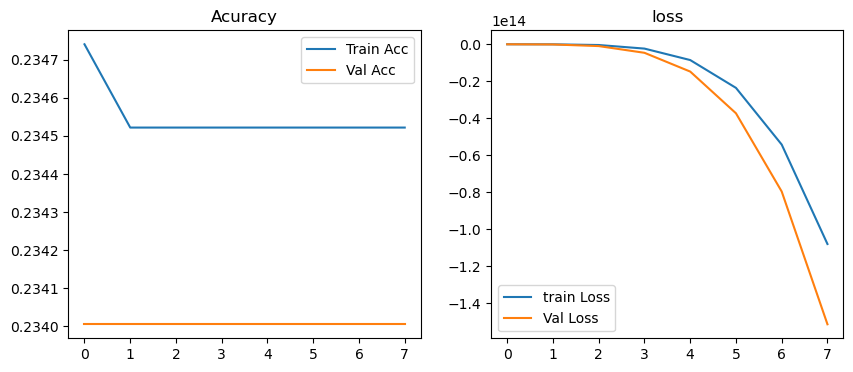

In [12]:
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(history.history["accuracy"],label="Train Acc")
plt.plot (history.history["val_accuracy"],label='Val Acc')
plt.legend(); plt.title("Acuracy")




plt.subplot(1,2,2)
plt.plot(history.history["loss"],label="train Loss")
plt.plot (history.history["val_loss"],label='Val Loss')
plt.legend(); plt.title("loss")
plt.show()



In [14]:
import os

test_dir = r"D:\\AII\\tumor\\Testing"
print(os.listdir(test_dir))


['glioma', 'meningioma', 'notumor', 'pituitary']


In [15]:

from tensorflow.keras.preprocessing import image
sample_image_path = os.path.join(test_dir, "glioma", os.listdir(os.path.join(test_dir, "glioma"))[0])

print(f"\n Testing sample image: {sample_image_path}")

img = image.load_img(sample_image_path, target_size=(128,128))
img_arr = image.img_to_array(img)/255.0
img_arr = np.expand_dims(img_arr, axis=0)

prediction = model.predict(img_arr)
class_names = list(test_data.class_indices.keys())
predicted_class = class_names[np.argmax(prediction)]

print(f" Predict Tumor Type: {predicted_class}")



 Testing sample image: D:\\AII\\tumor\\Testing\glioma\Te-glTr_0000.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step
 Predict Tumor Type: glioma
